### 目的
* 基于EC.SENESCENCE.SIG基因集，结合LUAD的转录组数据和甲基化数据通过ConsensusClusterPlus共识聚类进行分子分型。

### 环境配置

In [1]:
set.seed(42)

target_dir = "~/TCGA-LUAD/"
rna_meth_dir = paste0(target_dir, "result/preprocess/")
result_dir = paste0(target_dir, "result/Cox_all_subtype/")
if (!file.exists(result_dir)){
    dir.create(result_dir, recursive = TRUE)
}
print(result_dir)

[1] "~/TCGA-LUAD/result/Cox_all_subtype/"


### 数据收集
* TCGA-LUAD: 生存时间数据
* EC.SENESCENCE.SIG：102个内皮衰老基因（Wu Z, Uhl B, Gires O, Reichel CA. A transcriptomic pan-cancer signature for survival prognostication and prediction of immunotherapy response based on endothelial senescence. J Biomed Sci. 2023;30(1):21.)

### 生存时间数据

* 生存数据预处理

数据列定义：
  * sample: TCGA-XX-XXXX-XX，最后两位数字代表样本类型：-01 = 原发肿瘤（Primary Tumor）;-11 = 实体正常组织（Solid Tissue Normal）;-06 = 复发肿瘤（Recurrent Tumor）
  * PATIENT: 患者唯一 ID，同一个患者可能对应多个样本（如原发肿瘤 + 正常组织），用于关联同一患者的不同样本。
  * 总生存期（Overall Survival）: OS：事件标记，1 = 患者在随访期间死亡，0 = 截尾（存活 / 失访，未发生死亡事件）; OS.time：时间（单位：天），OS=1时为「诊断→死亡」天数；OS=0时为「诊断→最后随访 / 失访」天数。
  * 疾病特异性生存期（Disease-Specific Survival）: DSS：事件标记，1 = 患者因肺癌死亡，0 = 截尾（死于其他原因 / 存活）; DSS.time：时间（天），DSS=1时为「诊断→因肺癌死亡」天数；DSS=0时为「诊断→最后随访」天数。
  * 无病生存期（Disease-Free Interval）• DFI：事件标记，1 = 疾病复发 / 进展，0 = 截尾（无复发 / 进展）;• DFI.time：时间（天），DFI=1时为「诊断→复发 / 进展」天数；DFI=0时为「诊断→最后随访」天数。
  * 无进展生存期（Progression-Free Interval）:• PFI：事件标记，1 = 疾病进展 / 复发，0 = 截尾（无进展 / 复发）;• PFI.time：时间（天），PFI=1时为「诊断→进展 / 复发」天数；PFI=0时为「诊断→最后随访」天数。
  * Redaction: 数据编辑标记，因隐私 / 数据质量问题被编辑的记录

数据分析注意点：
  * 样本类型：-01/-11，筛选原发肿瘤 / 正常组织样本
  * 患者唯一性：生存分析通常以患者为单位（而非样本），因此需要确保每个 PATIENT 仅保留一条生存记录。优先保留原发肿瘤样本（sample 后缀 -01）的生存数据，因为正常组织样本的生存事件与肿瘤无关。若同一患者有多个原发肿瘤样本，推荐随访时间最长的一条。
  * 生存终点选择：最常用的终点是 OS（总生存期），因为数据最稳定、临床意义明确。若关注肿瘤特异性死亡，可选择 DSS；关注复发 / 进展，可选择 DFI/PFI。

In [2]:
library(dplyr)

# 读取生存时间数据
survival_data <- read.table(paste0(target_dir, "Curated survival data-survival_LUAD_survival.txt"), header=TRUE, sep="\t", check.names=FALSE, stringsAsFactors = FALSE)

# 筛选原发肿瘤样本
tumor_survival <- survival_data %>% filter(grepl("-01$", sample)) # 519  11
#print(dim(tumor_survival))

# 保留每个患者随访时间最长的记录
#tumor_survival <- tumor_survival[order(tumor_survival$`_PATIENT`, -tumor_survival$OS.time), ]
#patient_survival_max <- tumor_survival[!duplicated(tumor_survival$`_PATIENT`), ]
patient_survival_max <- tumor_survival %>% group_by(`_PATIENT`) %>% slice_max(order_by = OS.time, n = 1, with_ties = FALSE) %>% ungroup() 
# print(dim(patient_survival_max))  519  11

# Samples lacking survival time or status were removed while ensuring the included samples had a survival time > 0 day
patient_survival_max <- patient_survival_max[patient_survival_max$OS.time>0,]
# print(dim(patient_survival_max)) 515 11
head(patient_survival_max)

Warning message:
"package 'dplyr' was built under R version 4.5.2"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




sample,_PATIENT,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<lgl>
TCGA-05-4249-01,TCGA-05-4249,0,1523,0,1523,NA,NA,0,1523,NA
TCGA-05-4250-01,TCGA-05-4250,1,121,NA,121,NA,NA,0,121,NA
TCGA-05-4382-01,TCGA-05-4382,0,607,0,607,1,334,1,334,NA
TCGA-05-4384-01,TCGA-05-4384,0,426,0,426,NA,NA,1,183,NA
TCGA-05-4389-01,TCGA-05-4389,0,1369,0,1369,NA,NA,0,1369,NA
TCGA-05-4390-01,TCGA-05-4390,0,1126,0,1126,NA,NA,1,395,NA


* 将预处理后的甲基化数据和转录组数据与生存数据对齐

In [3]:
# 读取预处后的甲基化数据和转录组数据
meth_gene_matrix <- read.table(paste0(rna_meth_dir, "meth_gene_matrix_tumor.txt"), header=T, row.names=1, sep="\t", check.names = F) 
rna_exp_filtered <- read.table(paste0(rna_meth_dir, "rna_exp_filtered_tumor.txt"), header=T, row.names=1, sep="\t", check.names = F)
final_samples <- intersect(intersect(colnames(meth_gene_matrix), colnames(rna_exp_filtered)), patient_survival_max$sample)

# 过滤低变异特征 CV-相对变异, 按行计算
cv_rna <- apply(rna_exp_filtered, 1, function(x) sd(x)/mean(x))
cv_meth <- apply(meth_gene_matrix, 1, function(x) sd(x)/mean(x))

# 最终数据
rna_final <- rna_exp_filtered[cv_rna != 0,final_samples]
meth_final <- meth_gene_matrix[cv_meth >= 0.1,final_samples]
surv_final <- patient_survival_max[match(final_samples, patient_survival_max$sample),]

In [15]:
# 保存数据
meth_M_final <- log2( meth_final / (1 - meth_final + 1e-8))
write.table(rna_final, paste0(result_dir,"rna_final.txt"), sep="\t")
write.table(meth_final, paste0(result_dir,"meth_final.txt"), sep="\t")
write.table(meth_M_final, paste0(result_dir,"meth_M_final.txt"), sep="\t")
write.table(surv_final, paste0(result_dir,"surv_final.txt"), sep="\t")

### 提取EC.SENESCENCE.SIG基因集

In [4]:
# 读取EC.SENESCENCE.SIG
senescence_genes <- read.table(paste(target_dir, "EC.SENESCENCE.SIG.102.txt", sep=""), header=F)$V1
head(senescence_genes)

# 提取EC.SENESCENCE.SIG相关的表达与甲基化特征
rna_sen <- rna_final[rownames(rna_final) %in% senescence_genes,]
meth_sen <- meth_final[rownames(meth_final) %in% senescence_genes,]

# 合并特征
combine_rna_meth <- cbind(t(rna_sen), t(meth_sen))
colnames(combine_rna_meth) <- c(paste0(colnames(t(rna_sen)),"_rna"), paste0(colnames(t(meth_sen)), "_meth"))
cat("联合特征矩阵维度：", nrow(combine_rna_meth), "样本 ×", ncol(combine_rna_meth), "特征\n")

[1] "SLC9A3R2" "PLEKHG1"  "TMEM204"  "AFAP1L1"  "SYNPO"    "S100A16"

联合特征矩阵维度： 442 样本 × 132 特征


In [5]:
# meth convert beta to M， 防止产生NA
meth_beta <- t(meth_sen)
meth_M <- log2( meth_beta / (1 - meth_beta + 1e-8))
print(meth_M[is.infinite(meth_M)])
combine_rna_meth_M <- cbind(t(rna_sen), meth_M)
colnames(combine_rna_meth_M) <- c(paste0(colnames(t(rna_sen)),"_rna"), paste0(colnames(meth_M), "_meth"))

numeric(0)


In [6]:
# 保存数据
write.table(t(rna_sen), paste0(result_dir,"rna_sen.txt"), sep="\t")
write.table(t(meth_sen), paste0(result_dir,"meth_sen.txt"), sep="\t")
write.table(combine_rna_meth, paste0(result_dir,"combine_rna_meth_sen.txt"), sep="\t")
write.table(combine_rna_meth_M, paste0(result_dir,"combine_rna_meth_M_sen.txt"), sep="\t")

In [7]:
rm(survival_data, tumor_survival, meth_gene_matrix, rna_exp_filtered, final_samples)

gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,770991,41.2,2507780,134.0,2507780,134.0
Vcells,14260061,108.8,51153976,390.3,51153972,390.3


### 筛选与生存显著相关的特征————单因素Cox回归

In [8]:
library(survival)

cox_filter <- function(mat, surv_df){
    
    cox_full_result <- data.frame()
    
    # 批量单因素Cox
    cox_res <- lapply(colnames(mat), function(feature_name) {
        df <- data.frame(
                time = surv_df$OS.time,
                status = surv_df$OS,
                feature = mat[,feature_name]
            )
        
        tryCatch({
            withCallingHandlers({
          
                cx <- coxph(Surv(time, status) ~ feature, data=df)  
                cox_sum <- summary(cx)
            
                hr <- cox_sum$coefficients[,"exp(coef)"]        # 风险比HR
                ci_lower <- cox_sum$conf.int[,"lower .95"]      # 95%CI下限
                ci_upper <- cox_sum$conf.int[,"upper .95"]      # 95%CI上限
                pval <- cox_sum$coefficients[,"Pr(>|z|)"]       # P值

                data.frame(
                  Feature = feature_name,
                  HR = round(hr, 4),
                  HR_95CI_L = round(ci_lower, 4),
                  HR_95CI_U = round(ci_upper, 4),
                  Pvalue = signif(pval, 4)
                )
            }, 
            warning = function(w) {
                if (grepl("Loglik converged before variable  1 ; coefficient may be infinite. ", w$message)) {
                    stop("Perfect separation: ", w$message)
                } else {
                    warning(w)
                    return(NULL)
                }
            })
        },
        error=function(e){
            message("跳过异常特征: ", feature_name, " | 错误: ", e$message)
            return(NULL)
        })
    })

    cox_full_result <- do.call(rbind, cox_res)
    return(cox_full_result)
}

# 单因素cox回归
cox_result <- cox_filter(combine_rna_meth_M, surv_final)
#cox_result <- cox_result %>% 
#  mutate(FDR = p.adjust(Pvalue, method = "BH"))

# p<0.05生存显著相关
sig_features = cox_result$Feature[cox_result$Pvalue < 0.05]
cluster_data = combine_rna_meth[,sig_features]

cat("显著预后特征(p<0.05):", length(sig_features),"\n")
print(head(cox_result %>% filter(Pvalue<0.05), 10))

# 保存特征
write.table(cox_result, paste0(result_dir,"cox.sig.all.features.txt"), sep="\t")
write.table(cluster_data, paste0(result_dir,"cox.sig.0.05.features.txt"), sep="\t")

显著预后特征(p<0.05): 32 
      Feature     HR HR_95CI_L HR_95CI_U    Pvalue
1   ITGA5_rna 1.2206    1.0557    1.4113 0.0070950
2  COL4A1_rna 1.1813    1.0126    1.3780 0.0340600
3     PNP_rna 1.2663    1.0235    1.5667 0.0297000
4   MECOM_rna 0.8560    0.7596    0.9648 0.0108300
5   LAMB1_rna 1.3493    1.1368    1.6014 0.0006106
6  COX7A1_rna 0.8657    0.7496    0.9999 0.0498800
7    CAV2_rna 1.1495    1.0126    1.3049 0.0312700
8    STC1_rna 1.1378    1.0253    1.2626 0.0151200
9  LRRC8A_rna 1.4130    1.1251    1.7746 0.0029360
10 SCARF1_rna 0.7600    0.6459    0.8944 0.0009523


Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Warning message:
"package 'forestploter' was built under R version 4.5.3"


null device 
          1

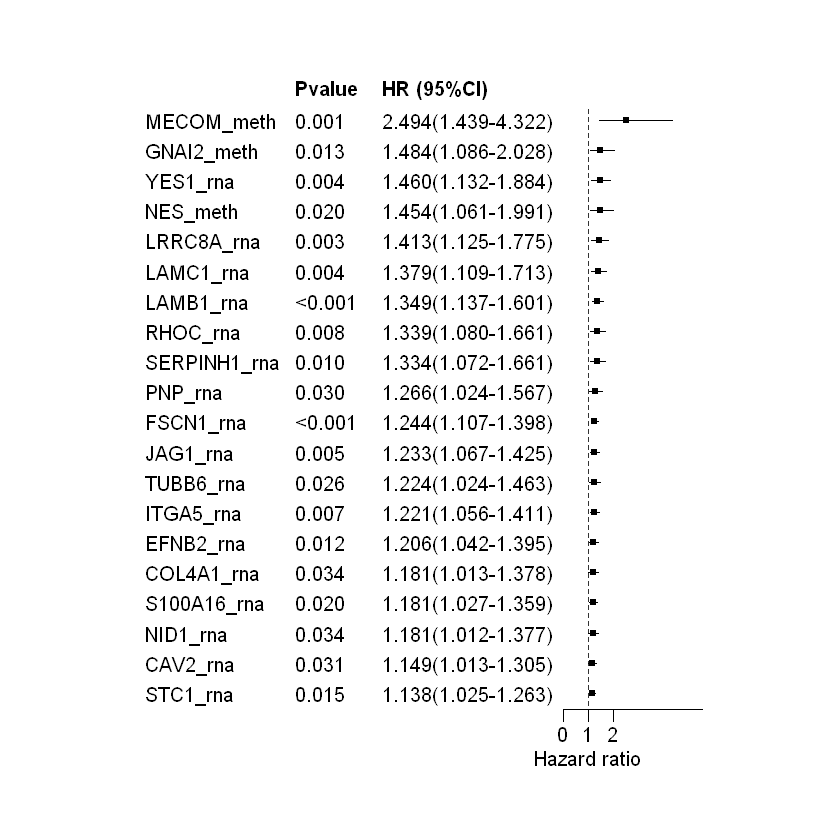

In [9]:
# 可视化
library(grid)
library(ggplot2)
library(forestploter)

plot_func <- function(top20_data, xlim_range=NULL, ticks_at=NULL) {

    top20_data <- rev(top20_data) 

    plot_text <- data.frame(
      `  ` = top20_data$Feature,
      Pvalue = ifelse(top20_data$Pvalue < 0.001, "<0.001", sprintf("%.3f", top20_data$Pvalue)),
      `HR (95%CI)` = paste0(sprintf("%.3f", top20_data$HR), "(", sprintf("%.3f", top20_data$HR_95CI_L), "-", sprintf("%.3f", top20_data$HR_95CI_U), ")"),
      check.names = FALSE
    )
    
    plot_text$` ` <- "                    " 
    
   # point_col <- ifelse(top20_data$HR > 1, "#FF0000", "#0066CC")
    
    tm <- forest_theme(
      refline_params = list(col = "black", lwd = 1, lty = 2), # 参考线（HR=1，黑色虚线）
      ci_params = list(col = "blue", lwd = 1.5, cap = 0.04),                # 置信区间线（蓝色）
      point_params = list(cex = 1.6),     # 点大小
      xaxis_params = list(col = "black", lwd = 1, fontsize = 10),             # X轴样式
      xlab_params = list(col = "black", fontface = "bold"),   # X轴标签样式
      text_params = list(col = "black", fontsize = 10),        # 文本样式
      core = list(bg_params = list(fill = "white", col = NA))# 背景样式
    )

    fp <- forest(
      data = plot_text,
      est = top20_data$HR,         # 风险比（HR）数值
      lower = top20_data$HR_95CI_L,    # 95%CI下限
      upper = top20_data$HR_95CI_U,    # 95%CI上限
      ci_column = 4,       # 森林图绘制在第4列（即空列` `）
      ref_line = 1,        # 参考线位置（HR=1）
      xlim = xlim_range,      # X轴范围（可调整为c(0,1.5)更贴合右侧图）
      ticks_at = ticks_at, # X轴刻度
      xlab = "Hazard ratio",
      col_width = c(0.25, 0.15, 0.3, 0.3), # 各列宽度比例
      theme = tm
    )

    return(fp)
}

forest_data <- cox_result %>% filter(Pvalue<0.05) %>%
    arrange(desc(HR)) %>% head(20) 

fp <- plot_func(forest_data, xlim_range=c(0, 5.5), ticks_at=c(0,1,2))
print(fp)
ggsave(paste0(result_dir, "RNA.Meth2gene.EC_SENESCENCE_Univariate_Cox_Forestplot.pdf"), fp, width = 10, height = 8, dpi = 300)
dev.off()

### 分子分型
* 基于显著后的特征进行聚类并分型

In [10]:
### Z-score 标准化
rna_features <- gsub("_rna", "", intersect(paste0(colnames(t(rna_sen)),"_rna"),sig_features))
meth_features <- gsub("_meth", "", intersect(paste0(colnames(meth_M),"_meth"), sig_features))
rna_scale <- scale(t(rna_sen)[,rna_features])
meth_scale <- scale(meth_M[, meth_features])
cluster_data_zs <- scale(cbind(rna_scale, meth_scale))
colnames(cluster_data_zs) <- c(paste0(colnames(rna_scale),"_rna"), paste0(colnames(meth_scale), "_meth"))

In [11]:
### 一致性聚类
library(ConsensusClusterPlus)
library(cluster)    # 轮廓系数
#library(fpc)        # CH指数
library(ggplot2)    
library(dplyr)     

set.seed(123)

cc_res = ConsensusClusterPlus(
    t(cluster_data_zs),
    maxK = 8, reps = 500, pItem = 0.8,
    clusterAlg = "hc", distance = "spearman", innerLinkage = "ward.D2", seed = 123,
    title = paste0(target_dir, "result/subtype/"), plot="pdf"
)
#iclres <- calcICL(cc_res,title="ConsensusClusterPlus")
# 上述运行后，subtype目录下生成consensus.pdf, 包含聚类图，cdf图，Delta area图，tracking plot

Warning message:
"package 'ConsensusClusterPlus' was built under R version 4.5.2"
end fraction

clustered

clustered

clustered

clustered

clustered

clustered

clustered



In [12]:
str(cc_res[[2]])

List of 5
 $ consensusMatrix: num [1:442, 1:442] 1 0.57 0.444 0.436 0.427 ...
 $ consensusTree  :List of 7
  ..$ merge      : int [1:441, 1:2] -3 -4 -5 -151 -218 -240 -276 -306 -6 -7 ...
  ..$ height     : num [1:441] 0 0 0 0 0 0 0 0 0 0 ...
  ..$ order      : int [1:442] 300 98 303 384 29 78 165 251 214 388 ...
  ..$ labels     : NULL
  ..$ method     : chr "average"
  ..$ call       : language hclust(d = as.dist(1 - fm), method = finalLinkage)
  ..$ dist.method: NULL
  ..- attr(*, "class")= chr "hclust"
 $ consensusClass : Named int [1:442] 1 1 2 2 2 1 2 1 1 2 ...
  ..- attr(*, "names")= chr [1:442] "TCGA-44-4112-01" "TCGA-NJ-A4YP-01" "TCGA-86-8278-01" "TCGA-62-A470-01" ...
 $ ml             : num [1:442, 1:442] 1 0.57 0.444 0.436 0.427 ...
 $ clrs           :List of 3
  ..$ : chr [1:442] "#A6CEE3" "#A6CEE3" "#1F78B4" "#1F78B4" ...
  ..$ : num 2
  ..$ : chr [1:2] "#A6CEE3" "#1F78B4"


In [13]:
### 最优K选择

k_range <- 2:8

# dist(t(cluster_data))是欧式距离， ConsensusClusterPlus设置的spearman,应保持一致, 若CCP是euclidean，则无需改
dist_mat <- as.dist(1 - cor(t(cluster_data_zs), method = "spearman"))

# 评估指标
eval_result <- lapply(k_range, function(k) {
    # 聚类标签
    label <- cc_res[[k]]$consensusClass

    # PAC值（越小越好）PAC = Proportion of ambiguous clustering 模糊聚类比例
    #cm <- cc_res[[k]]$consensusMatrix
    #pac <- sum(cm > 0.1 & cm < 0.9) / (length(cm) - ncol(cm))

    # 轮廓系数(越大越好)
    sil <- mean(silhouette(label, dist_mat)[,3])

    # CH指数(越大越好)
    #ch <- calinhara(t(cluster_data), label)

    # 每类样本数
    num <- table(label)

    data.frame(
        K=k,
        #PAC = round(pac,4),
        Silhouette = round(sil,4),
        #DeltaArea = round(delta, 4),
        #CH指数 = round(ch,2),
        Sample_N = paste(num, collapse = " | ")
    )
}) %>% bind_rows()

write.csv(eval_result, paste0(result_dir, "Cluster_K_evaluation.csv"), row.names = FALSE)

# 绘制PAC图
#pac_values <- sapply(k_range, function(k) {
#  cc_res[[k]]$PAC
#})
#pac_df <- data.frame(K=k_range, PAC=pac_values)
#p_pac <- ggplot(pac_df, aes(x=K, y=PAC, group=1)) +
#  geom_line(linewidth=1, color="blue") +
#  geom_point(size=3, color="red") +
#  labs(x="Number of Clusters (K)", y="PAC value") +
#  theme_bw() +
#  ggtitle("PAC for Optimal K Selection")
#ggsave(p_pac, paste0(result_dir, "PAC.pdf"), width=6, height=4, dpi=300)

# 绘制轮廓系数图
sil_score <- sapply(k_range, function(k) {
  mean(silhouette(cc_res[[k]]$consensusClass, dist_mat)[,3])
})
sil_df <- data.frame(K=k_range, Silhouette_Score=sil_score)

# group=1强制单条线（避免离散 K 被当成分类变量不连线）
p_sil <- ggplot(sil_df, aes(x=K, y=Silhouette_Score, group=1)) +
  geom_line(linewidth=0.5) +
  geom_point(size=3) +
  labs(x="Number of Clusters (K)", y="Mean Silhouette Score") +
  theme_bw() +
  ggtitle("Silhouette Score for Optimal K Selection")
ggsave(paste0(result_dir, "Silhouette_Score.pdf"), p_sil, width=6, height=4, dpi=300)

正在分析 K= 2 
Call:
survdiff(formula = Surv(OS.time, OS) ~ cluster, data = surv_data)

            N Observed Expected (O-E)^2/E (O-E)^2/V
cluster=1 276      118     95.4      5.38      13.4
cluster=2 166       42     64.6      7.93      13.4

 Chisq= 13.4  on 1 degrees of freedom, p= 3e-04 


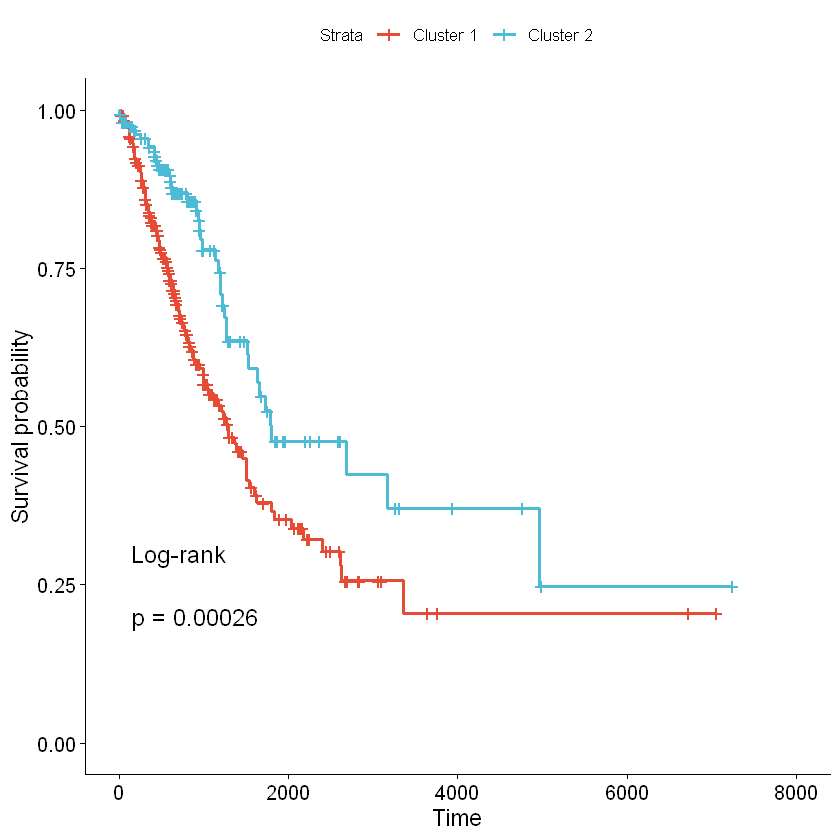

In [21]:
###候选聚类k + 生存分析
library(Rtsne)
library(survival)
library(survminer)

# 结合CDF 平缓点 + delta area 最稳定 + 轮廓系数最高点， 确定k=2为候选聚类数
candidate_k <- 2
# 可视化聚类效果
cluster_labels <- cc_res[[candidate_k]]$consensusClass
set.seed(42)
tsne_out <- Rtsne(
  cluster_data_zs,        
  dims = 2,          
  perplexity = 30,   # 样本量小就改 5~10
  check_duplicates = FALSE
)

tsne_df <- data.frame(
  tSNE_1 = tsne_out$Y[, 1],
  tSNE_2 = tsne_out$Y[, 2],
  Cluster = factor(cluster_labels, labels = c("Cluster 1", "Cluster 2"))
)

p_tsne <- ggplot(tsne_df, aes(x = tSNE_1, y = tSNE_2, color = Cluster)) +
  geom_point(size = 2.5) +
  stat_ellipse(linetype = 2, linewidth = 1) +  # 虚线分组圈
  scale_color_manual(values = c("#2EC4B6", "#E63946")) +
  theme_bw() +
  theme(panel.grid = element_blank(), legend.position = "right") +
  labs(x = "tSNE-1", y = "tSNE-2", title = "EC SENESCENCE Subtypes (K=2)")

ggsave(paste0(result_dir, "tSNE_Cluster_K2.pdf"), width = 8, height = 6, dpi = 300)

# 再结合生存曲线确定最终 K。
surv_result <- data.frame()

for (k in candidate_k) {
    cat("正在分析 K=", k, "\n")

    group_df <- data.frame(
        sample = names(cc_res[[k]]$consensusClass),
        cluster = factor(cc_res[[k]]$consensusClass)
    )
    surv_data <- inner_join(surv_final, group_df, by = "sample")

    # 拟合生存曲线
    fit <- survfit(Surv(OS.time, OS) ~ cluster, data = surv_data)

    # 样本校验：每组≥10例
    sample_pass <- all(table(surv_data$cluster) >= 10)
    diff <- survdiff(Surv(OS.time, OS) ~ cluster, data = surv_data)
    print(diff)
    p_value <- round(diff$p, 4)    

    surv_result <- rbind(surv_result, data.frame(K=k, Logrank_P=p_value, Sample_Pass=sample_pass))

    # KM曲线
    km_plot <- ggsurvplot(
      fit,
      pval = TRUE, pval.method = TRUE,
      legend.labs = paste0("Cluster ",1:k),
      palette = "npg", # 期刊配色
   )
   print(km_plot)
   ggsave(paste0(result_dir, paste0("KM_K",k,".pdf")), km_plot$plot, width=7, height=5, dpi=300)
}

write.csv(surv_result, paste0(result_dir, "Cluster_K_KM.csv"), row.names = FALSE)

In [15]:
### 确定最终最佳K
best_k <- candidate_k
best_cluster <- data.frame(
    sample = names(cc_res[[best_k]]$consensusClass),
    cluster = factor(cc_res[[best_k]]$consensusClass)
)

write.csv(best_cluster, paste0(result_dir, "best_K",best_k,"_sample_cluster.csv"), row.names=FALSE)

# 统计 
cat("最终最佳聚类数: K=", best_k, "\n")
cat("全程使用Spearman相关系数\n")
cat("样本分布：\n")
print(table(best_cluster$cluster))
cat("结果保存到：", result_dir, "\n")

最终最佳聚类数: K= 2 
全程使用Spearman相关系数
样本分布：

  1   2 
276 166 
结果保存到： C:\Users\wenfang\Desktop\TCGA-LUAD\result\Cox_all_subtype\ 


### 亚型间差异特征筛选
* 从两个亚型中，筛选出有生物学差异的特征，为后续预后模型做铺垫。

#### 转录组差异分析

In [16]:
library(limma)

# 读取亚型
cluster_df <- best_cluster
common_samples <- intersect(colnames(rna_final), cluster_df$sample)

cluster_lables <- cluster_df[match(common_samples, cluster_df$sample),]
cluster_factor <- factor(cluster_lables$cluster, levels = c(1,2), labels = c("C1", "C2"))

# 设计矩阵
design <- model.matrix(~0+cluster_factor)
colnames(design) <- c("C1", "C2")

# 差异分析
contrast.matrix <- makeContrasts(C2 - C1, levels = design)

# rna————DGE p<0.05，|logFC|>1
fit <- lmFit(as.matrix(rna_final), design)
fit2 <- contrasts.fit(fit, contrast.matrix)
fit2 <- eBayes(fit2)
rna_res <- topTable(fit2, coef=1, number=Inf, adjust="fdr")

# 汇总结果
rna_res_final <- data.frame(
    Gene = rownames(rna_res),
    logFC = rna_res$logFC,
    P.Value = rna_res$P.Value,
    adj.P.Val = rna_res$adj.P.Val
)

rna_deg <- subset(rna_res_final, adj.P.Val < 0.05 & abs(logFC) > 1.5)

head(rna_deg)

Warning message:
"package 'limma' was built under R version 4.5.2"


,Gene,logFC,P.Value,adj.P.Val
,<chr>,<dbl>,<dbl>,<dbl>
1,SUSD2,3.090462,8.221966e-56,1.514733e-51
2,CENPA,-2.019277,1.037950e-51,9.561078e-48
3,TPX2,-1.857809,5.983130e-49,3.674240e-45
4,HJURP,-1.858975,2.386583e-48,1.099200e-44
5,FAM83D,-1.675501,4.775989e-48,1.759761e-44
6,NEK2,-1.805647,1.212496e-47,3.489912e-44


In [17]:
rna_deg_1 <- subset(rna_res_final, adj.P.Val < 0.05 & abs(logFC) > 1)
print(dim(rna_deg_1))

rna_deg_1.5 <- subset(rna_res_final, adj.P.Val < 0.05 & abs(logFC) > 1.5)
print(dim(rna_deg_1.5))

[1] 1277    4
[1] 421   4


#### 甲基化差异分析

In [18]:
# meth
meth_beta <- meth_final
meth_M <- log2( meth_beta / (1 - meth_beta + 1e-8))
fit_meth <- lmFit(as.matrix(meth_M), design)
fit2_meth <- contrasts.fit(fit_meth, contrast.matrix)
fit2_meth2 <- eBayes(fit2_meth)
meth_res <- topTable(fit2_meth2, coef=1, number=Inf, adjust="fdr")

# delta beta 
samples_C1 <- cluster_lables$sample[cluster_lables$cluster == "1"]
samples_C2 <- cluster_lables$sample[cluster_lables$cluster == "2"]
beta_C1 <- rowMeans(meth_beta[, samples_C1], na.rm=TRUE)
beta_C2 <- rowMeans(meth_beta[, samples_C2], na.rm=TRUE)
delta_beta <- beta_C2 - beta_C1

# 汇总结果
meth_res_final <- data.frame(
    Gene = rownames(meth_res),
    logFC = meth_res$logFC,
    P.Value = meth_res$P.Value,
    adj.P.Val = meth_res$adj.P.Val,
    delta_beta = delta_beta[rownames(meth_res)]
)

In [19]:
meth_deg_0.2 <- subset(meth_res_final, adj.P.Val < 0.05 & abs(delta_beta) > 0.2)
print(dim(meth_deg_0.2))

meth_deg_0.1 <- subset(meth_res_final, adj.P.Val < 0.05 & abs(delta_beta) > 0.1)
print(dim(meth_deg_0.1))

[1] 0 5
[1] 66  5


In [20]:
# 保存数据
write.table(rna_res_final, paste0(result_dir,"rna_all.limma.C1.C2.features.txt"), sep="\t")
write.table(meth_res_final, paste0(result_dir,"meth_all.limma.C1.C2.features.txt"), sep="\t")